# 01 — Getting Started with the Three-Body Simulator

This notebook introduces the simulation suite step by step.

**What you will do:**
1. Run your first simulation (figure-eight choreography)
2. Plot the trajectories and verify conservation laws
3. Understand the state vector and ODE system
4. Compare two integrators side-by-side

**Physics covered:** Newton's law of gravitation, equations of motion, conservation of energy and angular momentum.

In [6]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt

from src.core.initial_conditions import figure_eight, build_state_vector, list_configurations
from src.core.integrator import integrate_scipy
from src.core.equations import transform_to_cm_frame, total_energy, G_UNITS
from src.visualization.visualize import plot_trajectories, plot_energy
from src.analysis.analysis import print_summary

print('✓ All imports successful')
print(f'G = {G_UNITS:.4f} AU³/(M☉·yr²)')

✓ All imports successful
G = 39.4784 AU³/(M☉·yr²)


## 1. Available Configurations

In [7]:
list_configurations()


Name                           Description                                                 
──────────────────────────────────────────────────────────────────────────────────────────
figure_eight                   Three equal-mass bodies chasing each other on a figure-8 ...
lagrange_triangle              Lagrange (1772): three equal-mass bodies at vertices of a...
pythagorean                    Masses 3,4,5 at rest at vertices of a right triangle. The...
solar_system                   Hierarchical triple: Sun (1 M☉), Jupiter (a=5.2 AU), Satu...
figure_eight_perturbed         Figure-8 choreography with 0.01 AU perturbation. The orbi...
sun_earth_moon                 Real Sun-Earth-Moon system (scaled). The Moon's orbit pre...



## 2. Load Figure-Eight Initial Conditions

The figure-eight is a **choreography solution** — all three bodies follow the same path, equally spaced in time. Discovered numerically by Moore (1993) and proven to exist by Chenciner & Montgomery (2000).

In [8]:
ic = figure_eight()

print(f"Name        : {ic['name']}")
print(f"Description : {ic['description'][:80]}...")
print(f"Reference   : {ic['reference']}")
print()
print(f"Masses: m1={ic['m1']} M☉, m2={ic['m2']} M☉, m3={ic['m3']} M☉")
print(f"r1 = {ic['r1']}  AU")
print(f"r2 = {ic['r2']}  AU")
print(f"r3 = {ic['r3']}  AU")
print(f"v1 = {ic['v1']}  AU/yr")
print(f"Estimated period: {ic['t_period']:.4f} yr")

Name        : Figure-Eight Choreography
Description : Three equal-mass bodies chasing each other on a figure-8 curve. Discovered by Mo...
Reference   : Chenciner & Montgomery (2000), Ann. Math. 152, 881

Masses: m1=1.0 M☉, m2=1.0 M☉, m3=1.0 M☉
r1 = [ 0.97000436 -0.24308753]  AU
r2 = [-0.97000436  0.24308753]  AU
r3 = [0. 0.]  AU
v1 = [0.93240737 0.86473146]  AU/yr
Estimated period: 1.0068 yr


## 3. The State Vector

The ODE integrator works on a flat state vector of length 12:
```
y = [x1, y1,  x2, y2,  x3, y3,  vx1, vy1,  vx2, vy2,  vx3, vy3]
     0   1    2   3    4   5     6    7      8    9      10   11
```

In [9]:
# Transform to center-of-mass frame first (eliminates linear drift)
r1, r2, r3, v1, v2, v3 = transform_to_cm_frame(
    ic['r1'], ic['r2'], ic['r3'],
    ic['v1'], ic['v2'], ic['v3'],
    ic['m1'], ic['m2'], ic['m3'],
)

ic_cm = dict(ic)
ic_cm.update({'r1':r1,'r2':r2,'r3':r3,'v1':v1,'v2':v2,'v3':v3})

y0 = build_state_vector(ic_cm)
print(f'State vector shape: {y0.shape}')
print(f'y0 = {y0}')

masses = np.array([ic['m1'], ic['m2'], ic['m3']])
E0 = total_energy(r1, r2, r3, v1, v2, v3, *masses)
print(f'\nInitial energy E₀ = {E0:.6f} M☉·AU²/yr²')

State vector shape: (12,)
y0 = [ 0.97000436 -0.24308753 -0.97000436  0.24308753  0.          0.
  0.93240737  0.86473146  0.93240737  0.86473146 -1.86481474 -1.72946292]

Initial energy E₀ = -93.844612 M☉·AU²/yr²


## 4. Run the Simulation

In [10]:
t_end = ic['t_end']   # 20 years
t_eval = np.linspace(0, t_end, 8000)

result = integrate_scipy(
    y0, masses,
    t_span=(0, t_end),
    t_eval=t_eval,
    method='DOP853',
    rtol=1e-10,
    atol=1e-12,
)

print_summary(result)

Three-Body Simulation
────────────────────────────────────────
  Integrator     : DOP853
  Duration       : 20.00 yr
  Steps          : 8000
  Max ΔE/E₀      : 8.42e-03
  Success        : True
  Masses (M☉)    : [1. 1. 1.]

  Max ΔE/E₀      : 8.42e-03
  Max ΔL/L₀      : 2.34e+22
  Min separation : 0.0063 AU (bodies 2-3 at t=2.61 yr)
  Ejection       : None detected



## 5. Plot Trajectories

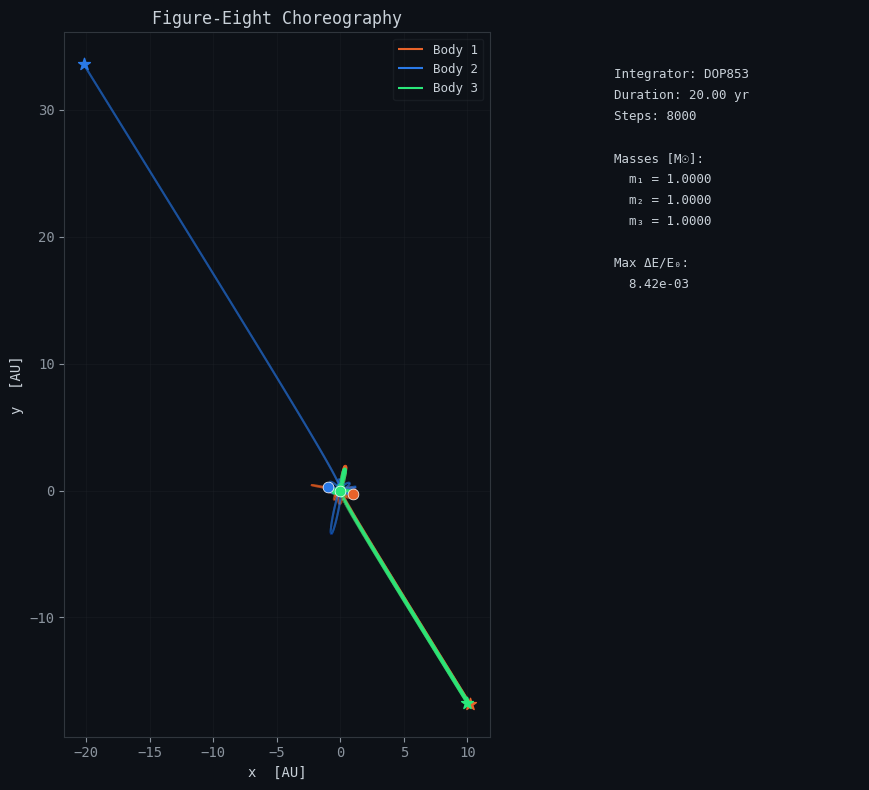

In [11]:
fig = plot_trajectories(result, title=ic['name'])
plt.show()

## 6. Verify Conservation Laws

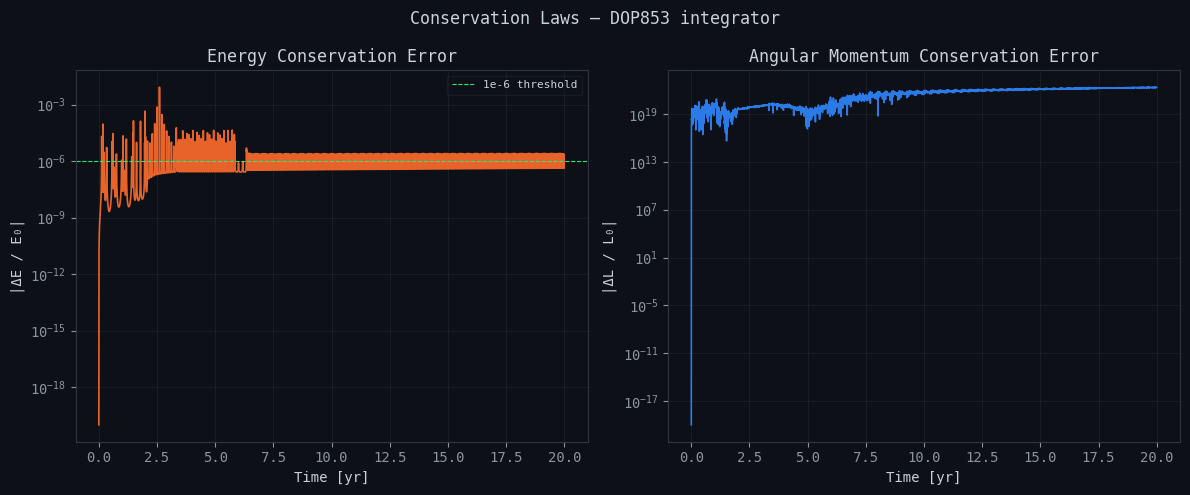

Max relative energy error    : 8.42e-03
Acceptable threshold         : 1e-6
Integration quality          : ✗ CHECK TOLERANCES


In [12]:
fig = plot_energy(result)
plt.show()

print(f'Max relative energy error    : {result.max_energy_error:.2e}')
print(f'Acceptable threshold         : 1e-6')
print(f'Integration quality          : {"✓ GOOD" if result.max_energy_error < 1e-6 else "✗ CHECK TOLERANCES"}')

## 7. Compare Integrators

Try RK45 vs DOP853 — which conserves energy better over long integration?

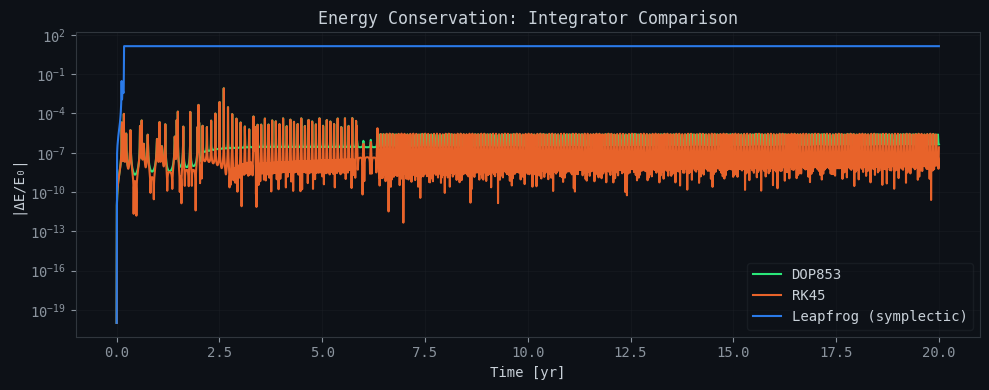

DOP853 max ΔE/E₀  : 8.42e-03
RK45   max ΔE/E₀  : 8.33e-03
Leapfrog max ΔE/E₀: 1.39e+01


In [13]:
from src.core.integrator import integrate_leapfrog

result_rk45 = integrate_scipy(y0, masses, (0, t_end), t_eval, method='RK45',   rtol=1e-10)
result_lf   = integrate_leapfrog(y0, masses, (0, t_end), dt=0.001)

fig, ax = plt.subplots(figsize=(10,4))
ax.semilogy(result.t,      result.energy_error      + 1e-20, label='DOP853', color='#2AE87A')
ax.semilogy(result_rk45.t, result_rk45.energy_error + 1e-20, label='RK45',   color='#E8632A')
ax.semilogy(result_lf.t,   result_lf.energy_error   + 1e-20, label='Leapfrog (symplectic)', color='#2A7AE8')
ax.set_xlabel('Time [yr]'); ax.set_ylabel('|ΔE/E₀|')
ax.set_title('Energy Conservation: Integrator Comparison')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'DOP853 max ΔE/E₀  : {result.max_energy_error:.2e}')
print(f'RK45   max ΔE/E₀  : {result_rk45.max_energy_error:.2e}')
print(f'Leapfrog max ΔE/E₀: {result_lf.max_energy_error:.2e}')

## ✅ Summary

You have:
- Loaded the figure-eight initial conditions
- Built and integrated the 12-dimensional ODE system
- Verified energy conservation (should be < 1e-6)
- Compared three integrators

**Next:** `02_famous_orbits.ipynb` — explore all six famous configurations including the chaotic Pythagorean problem.